# Qiskit Tutorial
By Olivier Lebreux

## Bloc 0 - Environment Setup

Before diving into the tutorial, we need to make sure everyone has the right tools installed. This block will guide you through setting up a clean Python environment and installing all the required dependencies.

** Estimated time : 5 minutes**

### Prerequisites

Make sure the following tools are installed on your system before proceeding.

- **Python 3.14.0**  — check with `python --version`
- **pip 23.0+** — check with `pip --version`
- **git** — check with `git --version`
- **nano** or any terminal text editor
- **conda** (optional) — only if you prefer conda over venv. 
  Miniconda is sufficient : https://docs.anaconda.com/miniconda/

### Setting Up a Virtual Environment

It is strongly recommended to work in a clean virtual environment to avoid 
dependency conflicts with your other Python projects. Choose **one** of the 
two options below — do not mix both.

#### Option 1 — venv

```bash
# Create the environment
python -m venv qiskit-env

# Activate it
source qiskit-env/bin/activate
```

#### Option 2 — conda

```bash
# Create the environment
conda create -n qiskit-env python=3.10

# Activate it
conda activate qiskit-env
```

> **Note :** You will need to activate your environment every time you open 
> a new terminal session before working with this notebook.

> **Tip :** New to virtual environments ? Check out this 
> [miniconda cheatsheet](https://docs.conda.io/projects/conda/en/4.6.0/_downloads/52a95608c49671267e40c689e0bc00ca/conda-cheatsheet.pdf) or this [venv cheatsheet](https://github.com/korolgroup/qiskit_tutorial/blob/OL_dev/venv_cheatsheet.md) for a quick reference.

### Installing Dependencies

#### Step 1 — Clone the repository

```bash
git clone https://github.com/korolgroup/qiskit_tutorial.git
cd qiskit_tutorial
```

#### Step 2 — Install the dependencies

```bash
pip install -r requirements.txt
```

> **Note :** Installation may take a few minutes, especially for PySCF.

> **Note :** This notebook is intended to be run in VS Code. Make sure you 
> have the **Jupyter extension** installed and that your virtual environment 
> is selected as the kernel before running any cells.

In [1]:
# Block 0 — Verification
# Run this cell to make sure all dependencies are correctly installed

import qiskit
import qiskit_nature
import qiskit_algorithms
import qiskit_aer
import pyscf
import numpy
import scipy
import matplotlib

print(f"Qiskit:            {qiskit.__version__}")
print(f"Qiskit Nature:     {qiskit_nature.__version__}")
print(f"Qiskit Algorithms: {qiskit_algorithms.__version__}")
print(f"Qiskit Aer:        {qiskit_aer.__version__}")
print(f"PySCF:             {pyscf.__version__}")
print(f"NumPy:             {numpy.__version__}")
print(f"SciPy:             {scipy.__version__}")
print(f"Matplotlib:        {matplotlib.__version__}")

print("\nAll dependencies are correctly installed!")

Qiskit:            2.3.1
Qiskit Nature:     0.7.2
Qiskit Algorithms: 0.4.0
Qiskit Aer:        0.17.2
PySCF:             2.12.1
NumPy:             2.4.4
SciPy:             1.17.1
Matplotlib:        3.10.8

All dependencies are correctly installed!


## Block 1 — Defining the Physical System

The first step in any quantum chemistry workflow is to define the molecular 
system we want to study. In Qiskit Nature, this is done by setting up a 
**driver** that interfaces with a classical chemistry package to compute 
the molecular integrals. In this tutorial, we use **PySCF** as our driver.

We will use the **H2 molecule** as our main example throughout this tutorial,
as it is the simplest molecule that captures the essential features of the 
workflow. The same approach can be applied to more complex molecules such as 
LiH, BeH2, or H2O with minimal changes.

### Defining the Molecular Geometry

To define our molecule, we need to specify a few key parameters that PySCF 
will use to compute the molecular integrals :

- **Geometry** : the atomic symbols and their 3D coordinates in Angstroms
- **Basis set** : the set of functions used to approximate the molecular 
  orbitals (e.g. `sto-3g`, `cc-pVDZ`)
- **Charge** : the total electric charge of the molecule
- **Spin multiplicity** : the number of unpaired electrons (0 for a 
  closed-shell singlet)

In [2]:
# Block 1 — Defining the Physical System

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit

# Define the H2 molecule
driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",  # Geometry in Angstroms
    basis="sto-3g",                # Basis set
    charge=0,                      # Neutral molecule
    spin=0,                        # Closed-shell singlet
    unit=DistanceUnit.ANGSTROM
)

# Run the driver to obtain the ElectronicStructureProblem
problem = driver.run()
print(problem)

### Other Molecules

The same workflow can be applied to more complex molecules by simply changing 
the `atom` and `basis` parameters. For example, for the **LiH molecule** :

```python
driver = PySCFDriver(
    atom="Li 0 0 0; H 0 0 1.596",
    basis="sto-3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)
```

Keep in mind that the complexity of the simulation grows rapidly with the number of electrons and orbitals.

## Block 2 — The Electronic Structure Problem

Now that we have defined our molecular system, we need to express it in a 
form that Qiskit Nature can work with. The `driver.run()` call from Block 1 
returns an `ElectronicStructureProblem` object, which encapsulates all the 
information about our molecule in the framework of **second quantization**.

In second quantization, the molecular Hamiltonian is expressed in terms of 
**fermionic creation and annihilation operators** acting on molecular 
orbitals, rather than on individual electron coordinates. This is the 
natural bridge between classical quantum chemistry and quantum computing.

In this block, we will :
- Explore the `ElectronicStructureProblem` object and its properties
- Extract and examine the second-quantized Hamiltonian
- Apply transformations to reduce the complexity of the problem

### Exploring the ElectronicStructureProblem Object

The `ElectronicStructureProblem` object contains all the information about 
our molecular system. Let's explore its key properties before moving on to 
the Hamiltonian.

In [3]:
# Block 2 — Exploring the ElectronicStructureProblem object

# Number of molecular orbitals and electrons
print(f"Number of molecular orbitals : {problem.num_spatial_orbitals}")
print(f"Number of particles : {problem.num_particles}")

# Reference energy (nuclear repulsion + HF energy)
print(f"Nuclear repulsion energy : {problem.nuclear_repulsion_energy}")

# List available properties
print(f"\nAvailable properties :")
for prop in problem.properties:
    print(f"  - {prop}")

Number of molecular orbitals : 2
Number of particles : (1, 1)
Nuclear repulsion energy : 0.7199689944489797

Available properties :
  - <qiskit_nature.second_q.properties.angular_momentum.AngularMomentum object at 0x11dedfa10>
  - <qiskit_nature.second_q.properties.magnetization.Magnetization object at 0x11dedfcb0>
  - <qiskit_nature.second_q.properties.particle_number.ParticleNumber object at 0x11dedfe00>
  - <qiskit_nature.second_q.properties.dipole_moment.ElectronicDipoleMoment object at 0x11e0e0050>


### The Second-Quantized Hamiltonian

The core of the `ElectronicStructureProblem` is the **second-quantized 
Hamiltonian**, which describes the electronic energy of the molecule in 
terms of fermionic creation and annihilation operators. We can extract it 
directly from the problem object and inspect its structure.

In [4]:
# Extract the second-quantized Hamiltonian
hamiltonian = problem.hamiltonian

# Get the fermionic operator
fermionic_op = hamiltonian.second_q_op()
print(f"Number of terms in the Hamiltonian : {len(fermionic_op)}")
print(f"\nFirst 5 terms :")
for term, coeff in list(fermionic_op.items())[:5]:
    print(f"  {term} : {coeff:.6f}")

Number of terms in the Hamiltonian : 36

First 5 terms :
  +_0 -_0 : -1.256339
  +_1 -_1 : -0.471896
  +_2 -_2 : -1.256339
  +_3 -_3 : -0.471896
  +_0 +_0 -_0 -_0 : 0.337855


### Reducing the Problem with Transformers

Before mapping our Hamiltonian to qubits, we can reduce the complexity of 
the problem by applying **transformers**. The `FreezeCoreTransformer` is 
one of the most useful — it freezes the core orbitals (the lowest energy 
orbitals that contribute little to the chemistry) and removes them from 
the active space.

This reduction directly translates to **fewer qubits** needed for the 
simulation, which is critical on current quantum hardware.

In [5]:
from qiskit_nature.second_q.transformers import FreezeCoreTransformer

# Apply the FreezeCoreTransformer
transformer = FreezeCoreTransformer()
reduced_problem = transformer.transform(problem)

# Compare the number of orbitals before and after
print(f"Original number of spatial orbitals : {problem.num_spatial_orbitals}")
print(f"Reduced number of spatial orbitals  : {reduced_problem.num_spatial_orbitals}")
print(f"\nOriginal number of particles : {problem.num_particles}")
print(f"Reduced number of particles  : {reduced_problem.num_particles}")

Original number of spatial orbitals : 2
Reduced number of spatial orbitals  : 2

Original number of particles : (1, 1)
Reduced number of particles  : (1, 1)


## Block 3 — Mapping the Hamiltonian to Qubits

So far, our Hamiltonian is expressed in terms of **fermionic operators**, 
which act on molecular orbitals. Quantum computers, however, work with 
**qubits and Pauli operators**. We therefore need a mapping that translates 
one representation into the other while preserving the physics of the problem.

### Jordan-Wigner Mapping

The **Jordan-Wigner mapping** is the most intuitive approach : each molecular 
spin-orbital is directly mapped to one qubit. A qubit in state |0⟩ represents 
an unoccupied orbital, and a qubit in state |1⟩ represents an occupied orbital.

The fermionic creation and annihilation operators are then expressed as 
combinations of Pauli operators (X, Y, Z), giving us a **qubit Hamiltonian** 
that a quantum computer can work with.

> **Note :** Other mapping schemes exist, such as **Bravyi-Kitaev** and 
> **Parity mapping**, which can reduce the complexity of the resulting 
> operator at the cost of a less intuitive representation.

In [6]:
from qiskit_nature.second_q.mappers import JordanWignerMapper

# Initialize the mapper
mapper = JordanWignerMapper()

# Map the second-quantized Hamiltonian to a qubit operator
fermionic_op = reduced_problem.hamiltonian.second_q_op()
qubit_op = mapper.map(fermionic_op)

# Inspect the resulting qubit operator
print(f"Number of qubits required : {qubit_op.num_qubits}")
print(f"Number of Pauli terms     : {len(qubit_op)}")
print(f"\nFirst 5 Pauli terms :")
for pauli, coeff in zip(qubit_op.paulis, qubit_op.coeffs):
    print(f"  {pauli} : {coeff:.6f}")

Number of qubits required : 4
Number of Pauli terms     : 15

First 5 Pauli terms :
  IIII : -0.810548+0.000000j
  IIIZ : 0.172184+0.000000j
  IIZI : -0.225753+0.000000j
  IZII : 0.172184+0.000000j
  ZIII : -0.225753+0.000000j
  IIZZ : 0.120913+0.000000j
  IZIZ : 0.168928+0.000000j
  ZIIZ : 0.166145+0.000000j
  YYYY : 0.045233+0.000000j
  XXYY : 0.045233+0.000000j
  YYXX : 0.045233+0.000000j
  XXXX : 0.045233+0.000000j
  IZZI : 0.166145+0.000000j
  ZIZI : 0.174643+0.000000j
  ZZII : 0.120913+0.000000j


## Block 4 — The Ansatz

Now that we have our qubit Hamiltonian, we need to prepare a **trial 
wavefunction** on the quantum computer. This is done through an **ansatz** 
— a parametric quantum circuit whose parameters will be optimized to 
minimize the energy of the system.

Choosing the right ansatz is a critical step : it must be expressive enough 
to capture the true ground state, while remaining shallow enough to be 
executable on current quantum hardware.

### UCCSD

The **Unitary Coupled Cluster Singles and Doubles (UCCSD)** ansatz is 
physically motivated — it is derived directly from the coupled cluster 
method in quantum chemistry. It systematically includes single and double 
excitations from a reference state (usually the Hartree-Fock state), making 
it highly accurate for molecular systems.

**Trade-off :** High accuracy, but deep circuits that are costly to run on 
real hardware.

### EfficientSU2

The **EfficientSU2** ansatz is a hardware-efficient circuit that uses 
alternating layers of single-qubit rotations and entangling gates. It has 
no direct physical motivation, but its shallow depth makes it much more 
suitable for current quantum hardware.

**Trade-off :** Shallower circuits, but may require more optimization 
iterations to converge and can miss important correlations.

> **Note :** The choice of ansatz is a fundamental challenge in variational 
> quantum algorithms and remains an active area of research.

In [7]:
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2

# --- UCCSD ---
# The Hartree-Fock state is used as the reference state for UCCSD
hf_state = HartreeFock(
    num_spatial_orbitals=reduced_problem.num_spatial_orbitals,
    num_particles=reduced_problem.num_particles,
    qubit_mapper=mapper
)

uccsd = UCCSD(
    num_spatial_orbitals=reduced_problem.num_spatial_orbitals,
    num_particles=reduced_problem.num_particles,
    qubit_mapper=mapper,
    initial_state=hf_state
)

# --- EfficientSU2 ---
efficient_su2 = EfficientSU2(
    num_qubits=qubit_op.num_qubits,
    reps=2,
    entanglement="linear"
)

# --- Compare the two ansatz ---
print(f"UCCSD circuit depth      : {uccsd.decompose().depth()}")
print(f"UCCSD number of params   : {uccsd.num_parameters}")
print(f"")
print(f"EfficientSU2 circuit depth    : {efficient_su2.depth()}")
print(f"EfficientSU2 number of params : {efficient_su2.num_parameters}")

UCCSD circuit depth      : 4
UCCSD number of params   : 3

EfficientSU2 circuit depth    : 1
EfficientSU2 number of params : 24


/var/folders/w8/ql2zsvts1d71_vpttpf8hs580000gn/T/ipykernel_3868/2386150680.py:20: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  efficient_su2 = EfficientSU2(


### Visualizing the Circuits

Let's visualize both circuits to get an intuition of their structure.

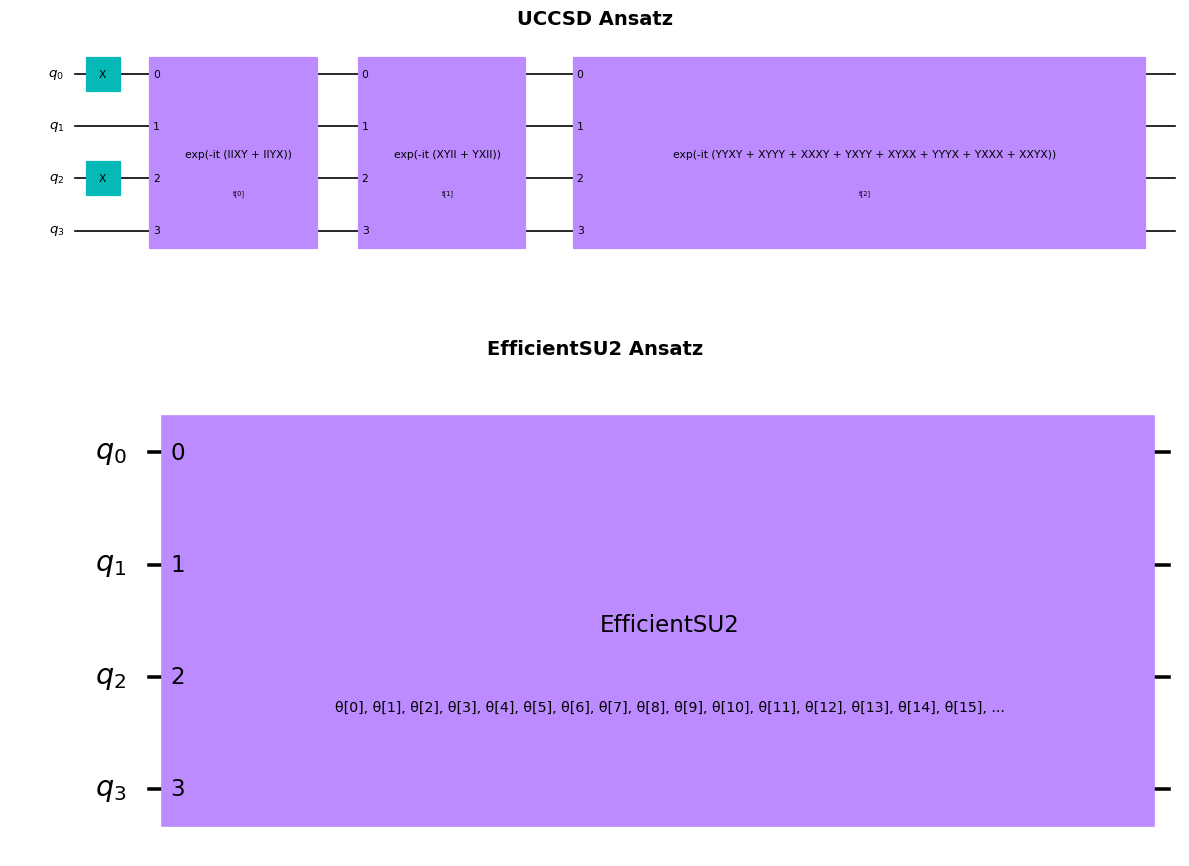

In [8]:
import matplotlib.pyplot as plt

# Draw both circuits
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

uccsd.decompose().draw(output="mpl", ax=axes[0], style="clifford")
axes[0].set_title("UCCSD Ansatz", fontsize=14, fontweight="bold")

efficient_su2.draw(output="mpl", ax=axes[1], style="clifford")
axes[1].set_title("EfficientSU2 Ansatz", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

## Block 5 — Ground State Solver

We now have all the ingredients to solve for the ground state energy of 
our molecule :
- A qubit Hamiltonian from Block 3
- An ansatz from Block 4

We will use two approaches and compare their results :

1. **NumPyEigensolver** : an exact classical solver that diagonalizes the 
   Hamiltonian directly. It gives us the exact ground state energy, but 
   scales exponentially with system size — making it impossible for large 
   molecules. We use it here as a **reference**.

2. **VQE (Variational Quantum Eigensolver)** : a hybrid quantum-classical 
   algorithm that uses our ansatz to prepare a trial state on the quantum 
   computer, and a classical optimizer to minimize the energy. 

In [9]:
import numpy as np

# Convert the qubit operator to a matrix representation
Hmat = qubit_op.to_matrix()
print(f"Hamiltonian matrix shape : {Hmat.shape}")

# Diagonalize the Hamiltonian matrix to obtain the exact eigenvalues
# Note : this approach is only feasible for small systems as the matrix
# grows exponentially with the number of qubits
E, S = np.linalg.eigh(Hmat)

# The ground state energy is the lowest eigenvalue
print(f"Ground state energy : {E[0]:.6f} Ha")


Hamiltonian matrix shape : (16, 16)
Ground state energy : -1.857275 Ha


In [10]:
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorEstimator as pEstimator

# Track the energy at each iteration
energy_history = []

def callback(eval_count, parameters, mean, std):
    energy_history.append(mean)

# Initialize the optimizer
cobyla = COBYLA(maxiter=500)

# Choose the ansatz to use for VQE
ansatz = uccsd  # You can switch to efficient_su2 if you want to test that ansatz instead

# Initialize the VQE
vqe = VQE(
    estimator=pEstimator(),
    ansatz=ansatz,
    optimizer=cobyla,
    callback=callback
)

# Solve for the ground state
result = vqe.compute_minimum_eigenvalue(qubit_op)
optimal_params = result.optimal_parameters
energie = result.eigenvalue.real

# Display the result
print(f"VQE ground state energy        : {energie:.6f} Ha")
print(f"NumPy ground state energy      : {E[0]:.6f} Ha")
print(f"Difference                     : {abs(energie - E[0]):.6f} Ha")
print(f"Number of iterations           : {len(energy_history)}")

/Users/olivierlebreux/Documents/StageÉté2026/Tool_presentation/qiskit-env/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/olivierlebreux/Documents/StageÉté2026/Tool_presentation/qiskit-env/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


VQE ground state energy        : -1.857275 Ha
NumPy ground state energy      : -1.857275 Ha
Difference                     : 0.000000 Ha
Number of iterations           : 58


### VQE Convergence

Let's visualize how the energy evolves over the optimization iterations.
A well-behaved VQE should converge smoothly toward the ground state energy.

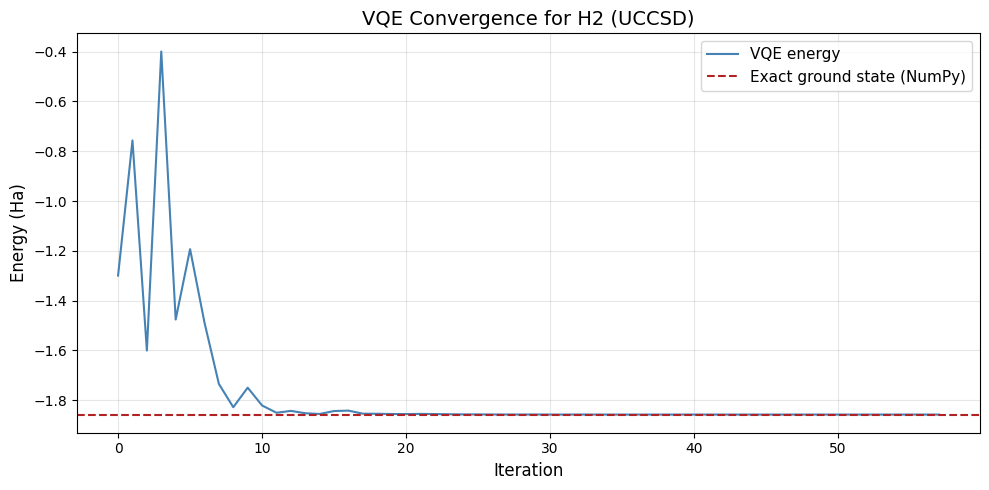

Final energy difference from exact : 0.000000 Ha


In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

# Plot the energy convergence
ax.plot(energy_history, color="steelblue", linewidth=1.5, label="VQE energy")

# Plot the exact ground state energy as a reference
ax.axhline(
    y=E[0],
    color="firebrick",
    linewidth=1.5,
    linestyle="--",
    label="Exact ground state (NumPy)"
)

# Labels and formatting
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Energy (Ha)", fontsize=12)
ax.set_title(f"VQE Convergence for H2 ({ansatz.__class__.__name__})", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final convergence message
final_diff = abs(energy_history[-1] - E[0])
print(f"Final energy difference from exact : {final_diff:.6f} Ha")